# Part 1c: Converting to an FPGA design with hls4ml

Now we will go through the steps to convert the model we trained to a low-latency FPGA design with hls4ml.
First, we will evaluate its classification performance to make sure we haven't lost accuracy using fixed-point data types.
Then we will synthesize the model with Vitis HLS and check the latency and FPGA resource usage.

Run either `1a_train_keras.ipynb` or `1b_train_pytorch.ipynb` first, then set `MODEL_TYPE` in the cell below accordingly.

In [1]:
MODEL_TYPE = 'keras'  # set to 'pytorch' if you used the PyTorch notebook

In [2]:
import os

os.environ['KERAS_BACKEND'] = 'tensorflow'

import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('..')
import plotting
import hls4ml

os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']

# Load the test dataset
X_test = np.ascontiguousarray(np.load('../data/jet-tagging/X_test.npy'), dtype=np.float32)
y_test = np.load('../data/jet-tagging/y_test.npy')
classes = np.load('../data/jet-tagging/classes.npy', allow_pickle=True)

## Load the trained model

In [3]:
if MODEL_TYPE == 'keras':
    import tensorflow as tf

    trained_model = tf.keras.models.load_model('../models/keras_model_part1.h5')
    y_model = trained_model.predict(X_test)

elif MODEL_TYPE == 'pytorch':
    import torch
    import torch.nn as nn

    # Architecture must match 1b_train_pytorch.ipynb
    class JetTagger(nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = nn.Linear(16, 64)
            self.fc2 = nn.Linear(64, 32)
            self.fc3 = nn.Linear(32, 32)
            self.output = nn.Linear(32, 5)

        def forward(self, x):
            x = torch.relu(self.fc1(x))
            x = torch.relu(self.fc2(x))
            x = torch.relu(self.fc3(x))
            return torch.softmax(self.output(x), dim=1)

    trained_model = JetTagger()
    trained_model.load_state_dict(torch.load('../models/pytorch_weights_part1.pt'))
    trained_model.eval()
    with torch.no_grad():
        y_model = trained_model(torch.FloatTensor(X_test)).numpy()

from sklearn.metrics import accuracy_score

print("Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_model, axis=1))))

I0000 00:00:1784145049.161701   22470 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784145049.212435   22470 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784145151.352054   22470 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1784145200.691397   22470 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


5188/5188 ━━━━━━━━━━━━━━━━━━━━ 7s 494us/step
Accuracy: 0.7630602409638554


## Make an hls4ml config & model

The hls4ml configuration is a dictionary that controls how the model is mapped to FPGA hardware. It exposes several knobs to tune the trade-off between latency, resource usage, and model accuracy:

- **Precision**: the fixed-point bit-width used for weights, biases, and accumulators. Reducing precision saves resources but can degrade accuracy unless the model was trained with quantization in mind. Covered in more details in **Part 2**.
- **Reuse factor**: controls parallelisation. A reuse factor of 1 gives maximum parallelism (lowest latency, most resources); higher values reuse the same hardware across multiple operations, saving resources at the cost of latency. Covered in **Part 3**.
- **I/O type**: controls how data is streamed through the network, which is particularly important for CNNs. Covered in **Part 4**.
- **Strategy**: selects the implementation algorithm, e.g. `Latency` or `Resource`.

In this part, we use the default hls4ml configuration to get a baseline design for the FPGA.

In [4]:
if MODEL_TYPE == 'keras':
    config = hls4ml.utils.config_from_keras_model(trained_model, granularity='model', backend='Vitis')
    hls_model = hls4ml.converters.convert_from_keras_model(
        trained_model,
        hls_config=config,
        backend='Vitis',
        output_dir='../hls4ml_prjs/hls4ml_prj_base_part1',
        part='xcu200-fsgd2104-2-e',
    )

elif MODEL_TYPE == 'pytorch':
    config = hls4ml.utils.config_from_pytorch_model(
        trained_model,
        input_shape=(16,),
        granularity='model',
        backend='Vitis',
    )
    hls_model = hls4ml.converters.convert_from_pytorch_model(
        trained_model,
        hls_config=config,
        backend='Vitis',
        output_dir='../hls4ml_prjs/hls4ml_prj_base_part1',
        part='xcu200-fsgd2104-2-e',
    )

print("-----------------------------------")
print("Configuration")
plotting.print_dict(config)
print("-----------------------------------")

-----------------------------------
Configuration
Model
  Precision
    default:         fixed<16,6>
  ReuseFactor:       1
  Strategy:          Latency
  BramFactor:        1000000000
  TraceOutput:       False
  BitExact:          None
-----------------------------------


Let's visualise what we created. The model architecture is shown, annotated with the shape and data types.

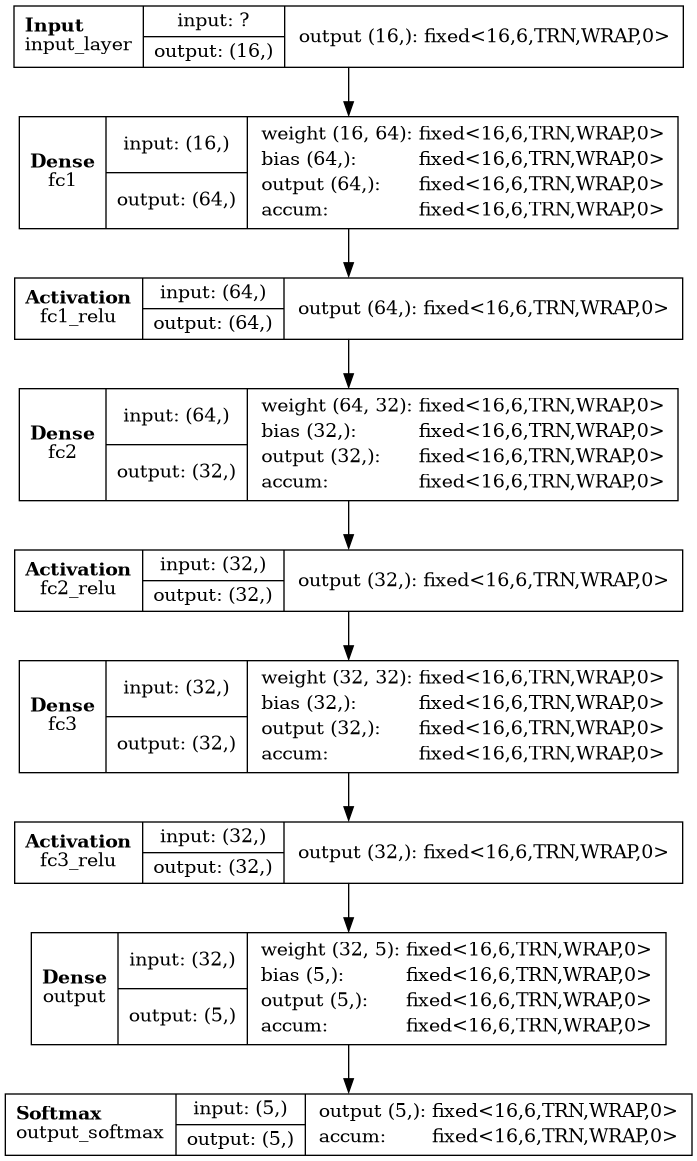

In [5]:
hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

## Compile & predict

hls4ml uses **fixed-point arithmetic** for everything on the FPGA — weights, biases, activations, and accumulators — as a form of post-training quantization. The default precision is `ap_fixed<16,6>` (16 bits total, 6 integer bits). This is in contrast to the CPU, which uses 32-bit floating-point throughout.

To confirm that this quantization has not degraded accuracy, we compile the hls4ml model and run `hls_model.predict`, which emulates the fixed-point FPGA design bit-accurately on the CPU. If the ROC curves match closely, the model performance is well-preserved after quantization.

Note that with the default 16-bit precision, accuracy is usually maintained without any special treatment. However, lower precisions and better resource savings can be achieved through *quantization-aware training* (QAT), which is further explored in **Part 2**.

In [6]:
hls_model.compile()
y_hls = hls_model.predict(X_test)

## Compare
That was easy! Now let's see how the performance compares to the original model:

keras Accuracy: 0.7630602409638554
hls4ml Accuracy: 0.7619397590361445


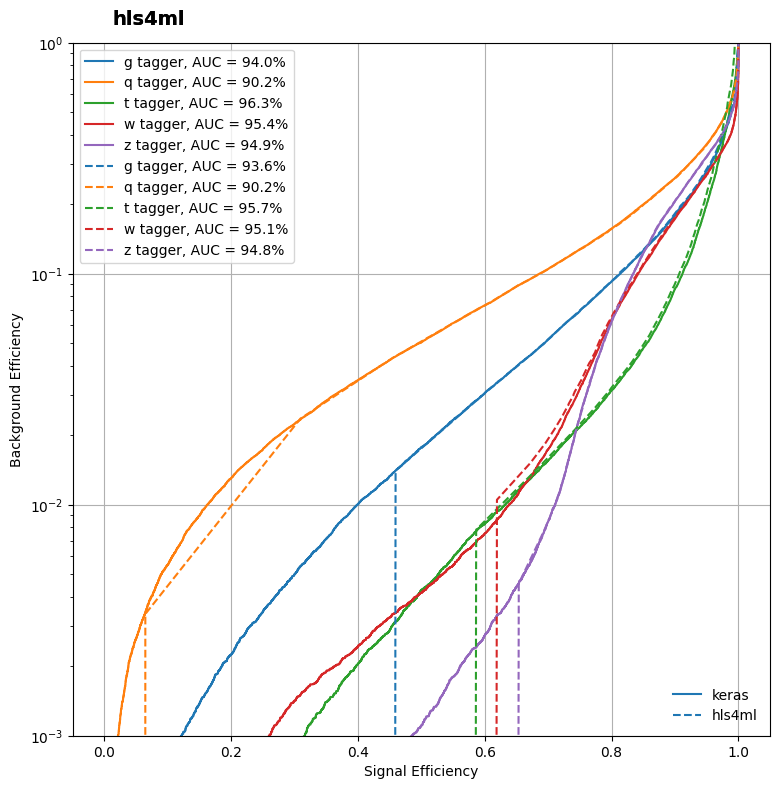

In [7]:
from sklearn.metrics import accuracy_score

print("{} Accuracy: {}".format(MODEL_TYPE, accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_model, axis=1))))
print("hls4ml Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))))

fig, ax = plt.subplots(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_model, list(classes))
plt.gca().set_prop_cycle(None)
_ = plotting.makeRoc(y_test, y_hls, list(classes), linestyle='--')

from matplotlib.lines import Line2D
from matplotlib.legend import Legend

lines = [Line2D([0], [0], ls='-'), Line2D([0], [0], ls='--')]
leg = Legend(ax, lines, labels=[MODEL_TYPE, 'hls4ml'], loc='lower right', frameon=False)
ax.add_artist(leg)

## Synthesize
Now we'll actually use Vitis HLS to synthesize the model. Vitis HLS compiles the HLS project into RTL, which can be exported as an FPGA IP and interated with a larger design, deployed on the FPGA.

In this tutorial, we will only review the HLS report, checking the latency and resource consumption.

**This can take several minutes.**

In [8]:
hls_model.build(csim=False)


****** vitis-run v2024.2 (64-bit)
  **** SW Build 5239630 on 2024-11-10-11:19:46
  **** Start of session at: Wed Jul 15 21:55:24 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2024.2 5238294
Sourcing Tcl script '/home/enlupi/Work/repo/hls4ml-tutorial/hls4ml_prjs/hls4ml_prj_base_part1/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project myproject_prj 
INFO: [HLS 200-10] Opening project '/home/enlupi/Work/repo/hls4ml-tutorial/hls4ml_prjs/hls4ml_prj_base_part1/myproject_prj'.
INFO: [HLS 200-1510] Running: set_top myproject 
INFO: [HLS 200-1510] Running: add_files firmware/myproject.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding design file 'firmware/myproject.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb myproject_test.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding test bench file 'myproject_test.cpp' to the project
INFO: [HLS 200-1510] Running: 

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.490',
  'BestLatency': '15',
  'WorstLatency': '15',
  'IntervalMin': '1',
  'IntervalMax': '1',
  'BRAM_18K': '5',
  'DSP': '3339',
  'FF': '25478',
  'LUT': '124856',
  'URAM': '0',
  'AvailableBRAM_18K': '4320',
  'AvailableDSP': '6840',
  'AvailableFF': '2364480',
  'AvailableLUT': '1182240',
  'AvailableURAM': '960'}}

# Check the reports
Print out the reports generated by Vitis HLS. Pay attention to the Latency and the 'Utilization Estimates' sections.

In [9]:
hls4ml.report.read_vivado_report('../hls4ml_prjs/hls4ml_prj_base_part1')

Found 1 solution(s) in ../hls4ml_prjs/hls4ml_prj_base_part1/myproject_prj.
Reports for solution "solution1":

C simulation report not found.
SYNTHESIS REPORT:
== Vitis HLS Report for 'myproject'
* Date:           Wed Jul 15 22:02:46 2026

* Version:        2024.2 (Build 5238294 on Nov  8 2024)
* Project:        myproject_prj
* Solution:       solution1 (Vivado IP Flow Target)
* Product family: virtexuplus
* Target device:  xcu200-fsgd2104-2-e


== Performance Estimates
+ Timing: 
    * Summary: 
    +--------+---------+----------+------------+
    |  Clock |  Target | Estimated| Uncertainty|
    +--------+---------+----------+------------+
    |ap_clk  |  5.00 ns|  3.490 ns|     1.35 ns|
    +--------+---------+----------+------------+

+ Latency: 
    * Summary: 
    +---------+---------+-----------+-----------+-----+-----+---------+
    |  Latency (cycles) |   Latency (absolute)  |  Interval | Pipeline|
    |   min   |   max   |    min    |    max    | min | max |   Type  |
    +----

## A note on DSP usage

You may notice that the baseline design uses a significant number of **DSPs** (Digital Signal Processing blocks). This is because the default weight and activation precision is `ap_fixed<16,6>` — 16-bit fixed-point. Generally, multiplications with precisions wider than 10 bits are mapped to DSPs, while narrower multiplications are implemented with LUTs.

FPGAs typically have far more LUTs than DSPs — the Alveo U250, for example, has ~1.7 million LUTs but only ~12,288 DSPs; limiting the scale of our design.

The easiest way to reduce DSP consumption is by reducing variable precision through **quantization-aware training (QAT)**, which is covered in more details in **Part 2** with QKeras and Brevitas.

# A note on resource estimates

The resource numbers reported by Vitis HLS after HLS C-synthesis are **estimates** derived from the HLS's internal model and often do not truly reflect the final resource consumption of the model. These estimates **often overestimate** LUT consumption, sometimes by an order of magnitude.

For a more accurate picture of resource consumption, you should run **Vivado synthesis** (`vsynth`). This invokes the full Vivado synthesis flow on the generated RTL, producing estimates that are much closer to what you would see after implementation (place-and-route).

**This step can take 10–20 minutes.**

In [10]:
hls_model.build(reset=False, csim=False, vsynth=True)


****** vitis-run v2024.2 (64-bit)
  **** SW Build 5239630 on 2024-11-10-11:19:46
  **** Start of session at: Wed Jul 15 22:03:07 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

  **** HLS Build v2024.2 5238294
Sourcing Tcl script '/home/enlupi/Work/repo/hls4ml-tutorial/hls4ml_prjs/hls4ml_prj_base_part1/build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project myproject_prj 
INFO: [HLS 200-10] Opening project '/home/enlupi/Work/repo/hls4ml-tutorial/hls4ml_prjs/hls4ml_prj_base_part1/myproject_prj'.
INFO: [HLS 200-1510] Running: set_top myproject 
INFO: [HLS 200-1510] Running: add_files firmware/myproject.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding design file 'firmware/myproject.cpp' to the project
INFO: [HLS 200-1510] Running: add_files -tb myproject_test.cpp -cflags -std=c++0x 
INFO: [HLS 200-10] Adding test bench file 'myproject_test.cpp' to the project
INFO: [HLS 200-1510] Running: 

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '3.490',
  'BestLatency': '15',
  'WorstLatency': '15',
  'IntervalMin': '1',
  'IntervalMax': '1',
  'BRAM_18K': '5',
  'DSP': '3339',
  'FF': '25478',
  'LUT': '124856',
  'URAM': '0',
  'AvailableBRAM_18K': '4320',
  'AvailableDSP': '6840',
  'AvailableFF': '2364480',
  'AvailableLUT': '1182240',
  'AvailableURAM': '960'},
 'VivadoSynthReport': {'LUT': '65556',
  'FF': '24618',
  'BRAM_18K': '2',
  'URAM': '0',
  'DSP48E': '3326'}}